# 21 — Malignant-state pseudobulk differential expression / marker refinement

This notebook is the repository-numbered equivalent of the historical executed notebook:

`20_malignant_state_pseudobulk_DE_HVG8000_r0_6.ipynb`

The pseudobulk definitions, thresholds, logCPM transformation, Mann-Whitney U state-vs-rest tests, Benjamini-Hochberg correction, marker filters, top-marker ranking, heatmap logic, and historical output names are preserved.

## Historical pseudobulk design

- unit: `sample × malignant_state`;
- malignant states: the five canonical states from Notebook 20;
- minimum cells per pseudobulk for DE: `30`;
- minimum pseudobulks per tested group: `3`;
- marker filter:
  - detected in at least `10%` of state pseudobulks;
  - BH-FDR `<= 0.05`;
  - absolute logCPM difference `>= 0.25`;
- top export: `100` up and `100` down genes per state;
- random seed: `42`.

## Canonical input policy

This notebook requires the canonical Notebook-20 H5AD:

`GBM_core_4datasets_final_annotation_malignant_states.h5ad`

No fallback to a pre-malignant-state object is allowed. Before aggregation, canonical cell/gene counts and exact malignant-state counts are checked.

## Memory-safety and power-recovery policy

The historical notebook loaded the full 351,427 × 15,176 H5AD and then copied the 161,884 malignant-state cells, including the enormous raw-count layer, into memory.

This implementation does not materialize the full expression matrix or the malignant-cell expression subset.

- `/obs` and `/var` are read with `h5py/read_elem`.
- `/layers/counts` is streamed sequentially from the canonical H5AD.
- Source rows are processed in independent chunks.
- Each completed chunk is aggregated to the 375 historical sample-state pseudobulks and saved atomically under local scratch.
- If power is interrupted, completed chunk files are reused on the next run.
- The final 375 × 15,176 pseudobulk matrix is small enough to keep in memory.
- Historical pseudobulk logCPM and DE calculations then run exactly on that final matrix.
- Scratch chunk files are removed only after all final checkpoints pass.

The scientific/statistical semantics are unchanged.

## Marker-ranking checkpoint note

The historical notebook uses two intentionally different marker rankings. `top_df` is ordered by adjusted p-value, raw p-value, and logCPM difference, whereas the marker-refinement summary is ordered by adjusted p-value and logCPM difference. The executed historical notebook explicitly displays `KCNN3` as the first AC-like gene in the refinement-summary ranking, not as the first row of `top_df`. Repository hard checks therefore validate marker identity against the exact historical output in which it is actually shown.


In [1]:
# =========================
# 0. Imports and configuration
# =========================
from pathlib import Path
import os
import gc
import shutil
import warnings

import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.stats import mannwhitneyu

import anndata as ad
import h5py
import matplotlib.pyplot as plt

try:
    from anndata.io import read_elem
except Exception:
    from anndata._io.specs import read_elem

try:
    from statsmodels.stats.multitest import multipletests
    HAS_STATSMODELS = True
except Exception:
    HAS_STATSMODELS = False

warnings.filterwarnings("ignore")


def find_repository_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    start = start.expanduser().resolve()

    for candidate in (start, *start.parents):
        if (
            (candidate / "README.md").exists()
            and (candidate / "code").exists()
            and (candidate / "metadata").exists()
        ):
            return candidate

    return start


PROJECT_DIR = Path(
    os.environ.get(
        "GLIOMA_PROJECT_ROOT",
        find_repository_root(),
    )
).expanduser().resolve()

PROCESSED_DIR = (
    PROJECT_DIR
    / "data"
    / "processed"
    / "integrated"
)

METADATA_DIR = (
    PROJECT_DIR
    / "metadata"
)

FIGURES_DIR = (
    PROJECT_DIR
    / "figures"
    / "malignant_state_pseudobulk_DE_HVG8000_r0_6"
)

for directory in [
    PROCESSED_DIR,
    METADATA_DIR,
    FIGURES_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


INPUT_H5AD = (
    PROCESSED_DIR
    / "GBM_core_4datasets_final_annotation_malignant_states.h5ad"
)

PSEUDOBULK_H5AD = (
    PROCESSED_DIR
    / "GBM_core_4datasets_malignant_state_pseudobulk_logCPM.h5ad"
)


READINESS_TSV = (
    METADATA_DIR
    / "malignant_pseudobulk_DE_readiness_HVG8000_r0_6.tsv"
)

PSEUDOBULK_QC_TSV = (
    METADATA_DIR
    / "malignant_pseudobulk_sample_state_QC_HVG8000_r0_6.tsv"
)

STATE_SUMMARY_TSV = (
    METADATA_DIR
    / "malignant_pseudobulk_state_summary_HVG8000_r0_6.tsv"
)

DE_TOP100_TSV = (
    METADATA_DIR
    / "malignant_state_pseudobulk_DE_state_vs_rest_top100_up_down_HVG8000_r0_6.tsv"
)

DE_SIGNIFICANT_TSV = (
    METADATA_DIR
    / "malignant_state_pseudobulk_DE_state_vs_rest_significant_HVG8000_r0_6.tsv"
)

DE_ALL_SUMMARY_TSV = (
    METADATA_DIR
    / "malignant_state_pseudobulk_DE_state_vs_rest_test_summary_HVG8000_r0_6.tsv"
)

REFINEMENT_SUMMARY_TSV = (
    METADATA_DIR
    / "malignant_state_marker_refinement_summary_HVG8000_r0_6.tsv"
)

FIGURE_MANIFEST_TSV = (
    METADATA_DIR
    / "malignant_state_pseudobulk_DE_figure_manifest_HVG8000_r0_6.tsv"
)

OUTPUT_MANIFEST_TSV = (
    METADATA_DIR
    / "malignant_state_pseudobulk_DE_output_manifest_HVG8000_r0_6.tsv"
)

MEAN_EXPR_TSV = (
    METADATA_DIR
    / "malignant_state_pseudobulk_top_marker_mean_logCPM_matrix_HVG8000_r0_6.tsv"
)


MIN_CELLS_PER_PSEUDOBULK = 30
MIN_PSEUDOBULKS_PER_GROUP = 3
MIN_DETECTED_FRACTION_IN_STATE = 0.10
MIN_ABS_LOGFC_FOR_REPORT = 0.25
SIGNIFICANT_PADJ = 0.05
TOP_N_PER_DIRECTION = 100
RANDOM_SEED = 42

np.random.seed(
    RANDOM_SEED
)


def choose_scratch_root():
    candidates = []

    env_scratch = os.environ.get(
        "GLIOMA_SCRATCH_ROOT"
    )

    if env_scratch:
        candidates.append(
            Path(
                env_scratch
            )
            / "main_analysis_21"
        )

    if os.name == "nt":
        candidates.append(
            Path(
                r"E:\glioma-cnv-scratch\main_analysis_21"
            )
        )

    candidates.append(
        PROJECT_DIR
        / "data"
        / "interim"
        / "scratch_main_analysis_21"
    )

    for candidate in candidates:
        try:
            candidate.mkdir(
                parents=True,
                exist_ok=True,
            )

            if candidate.exists():
                return candidate.resolve()

        except Exception:
            continue

    raise RuntimeError(
        "Could not create a writable Notebook-21 scratch directory."
    )


SCRATCH_DIR = choose_scratch_root()

CHUNK_DIR = (
    SCRATCH_DIR
    / "pseudobulk_count_chunks"
)

CHUNK_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


print(
    "Historical notebook mapping:",
    "20_malignant_state_pseudobulk_DE_HVG8000_r0_6.ipynb "
    "-> 21_malignant_state_pseudobulk.ipynb",
)

print(
    "Input h5ad:",
    INPUT_H5AD,
)

print(
    "Output pseudobulk h5ad:",
    PSEUDOBULK_H5AD,
)

print(
    "Scratch:",
    SCRATCH_DIR,
)


if not INPUT_H5AD.exists():
    raise FileNotFoundError(
        "Notebook 21 requires the canonical Notebook-20 malignant-state H5AD:\n"
        f"{INPUT_H5AD}"
    )


Historical notebook mapping: 20_malignant_state_pseudobulk_DE_HVG8000_r0_6.ipynb -> 21_malignant_state_pseudobulk.ipynb
Input h5ad: G:\Repository\glioma-cnv-single-cell-atlas\data\processed\integrated\GBM_core_4datasets_final_annotation_malignant_states.h5ad
Output pseudobulk h5ad: G:\Repository\glioma-cnv-single-cell-atlas\data\processed\integrated\GBM_core_4datasets_malignant_state_pseudobulk_logCPM.h5ad
Scratch: E:\glioma-cnv-scratch\main_analysis_21


In [2]:
# =========================
# 1. Helper functions
# =========================
def write_tsv_replace(
    df,
    path,
):
    path = Path(
        path
    )

    path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    tmp = path.with_suffix(
        path.suffix
        + ".tmp"
    )

    if tmp.exists():
        tmp.unlink()

    df.to_csv(
        tmp,
        sep="\t",
        index=False,
    )

    os.replace(
        tmp,
        path,
    )

    print(
        f"[SAVED] {path} shape={df.shape}"
    )


def write_h5ad_replace(
    adata_obj,
    path,
):
    path = Path(
        path
    )

    path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    tmp = path.with_suffix(
        path.suffix
        + ".tmp"
    )

    if tmp.exists():
        tmp.unlink()

    adata_obj.write_h5ad(
        tmp
    )

    os.replace(
        tmp,
        path,
    )

    print(
        f"[SAVED] {path}"
    )


def choose_first_existing_column(
    df,
    candidates,
    required=True,
    label="column",
):
    for candidate in candidates:
        if candidate in df.columns:
            return candidate

    if required:
        raise KeyError(
            f"Could not find {label}. "
            f"Tried: {candidates}. "
            f"Available columns include: {list(df.columns)[:80]}"
        )

    return None


def benjamini_hochberg(
    pvals,
):
    pvals = np.asarray(
        pvals,
        dtype=float,
    )

    out = np.full_like(
        pvals,
        np.nan,
        dtype=float,
    )

    mask = np.isfinite(
        pvals
    )

    if mask.sum() == 0:
        return out

    p = pvals[
        mask
    ]

    n = len(
        p
    )

    order = np.argsort(
        p
    )

    ranked = p[
        order
    ]

    q = (
        ranked
        * n
        / (
            np.arange(
                n
            )
            + 1
        )
    )

    q = np.minimum.accumulate(
        q[
            ::-1
        ]
    )[
        ::-1
    ]

    q = np.clip(
        q,
        0,
        1,
    )

    tmp = np.empty(
        n
    )

    tmp[
        order
    ] = q

    out[
        mask
    ] = tmp

    return out


def fdr_adjust(
    pvals,
):
    if HAS_STATSMODELS:
        p = np.asarray(
            pvals,
            dtype=float,
        )

        out = np.full_like(
            p,
            np.nan,
            dtype=float,
        )

        mask = np.isfinite(
            p
        )

        if mask.sum() > 0:
            out[
                mask
            ] = multipletests(
                p[
                    mask
                ],
                method="fdr_bh",
            )[
                1
            ]

        return out

    return benjamini_hochberg(
        pvals
    )


def safe_mwu(
    x,
    y,
):
    x = np.asarray(
        x,
        dtype=float,
    )

    y = np.asarray(
        y,
        dtype=float,
    )

    x = x[
        np.isfinite(
            x
        )
    ]

    y = y[
        np.isfinite(
            y
        )
    ]

    if (
        len(
            x
        )
        < MIN_PSEUDOBULKS_PER_GROUP
        or len(
            y
        )
        < MIN_PSEUDOBULKS_PER_GROUP
    ):
        return np.nan

    if (
        np.allclose(
            x,
            x[
                0
            ],
        )
        and np.allclose(
            y,
            y[
                0
            ],
        )
        and np.isclose(
            x[
                0
            ],
            y[
                0
            ],
        )
    ):
        return 1.0

    try:
        return float(
            mannwhitneyu(
                x,
                y,
                alternative="two-sided",
            ).pvalue
        )

    except Exception:
        return np.nan


def sanitize_filename(
    value,
):
    return (
        str(
            value
        )
        .replace(
            "/",
            "_",
        )
        .replace(
            " ",
            "_",
        )
        .replace(
            "-",
            "_",
        )
        .replace(
            "(",
            "",
        )
        .replace(
            ")",
            "",
        )
    )


def decode_h5_attr(
    value,
):
    if isinstance(
        value,
        (
            bytes,
            np.bytes_,
        ),
    ):
        return value.decode(
            "utf-8"
        )

    return str(
        value
    )


def load_valid_chunk(
    path,
    expected_shape,
):
    path = Path(
        path
    )

    if not path.exists():
        return None

    try:
        matrix = sp.load_npz(
            path
        ).tocsr()

        if matrix.shape != expected_shape:
            raise ValueError(
                f"shape {matrix.shape} != {expected_shape}"
            )

        if not matrix.has_canonical_format:
            matrix.sum_duplicates()
            matrix.sort_indices()

        return matrix

    except Exception as error:
        print(
            "[INVALID CHUNK — REBUILD]",
            path.name,
            repr(
                error
            ),
        )

        try:
            path.unlink()
        except Exception:
            pass

        return None


def save_sparse_chunk_atomic(
    matrix,
    path,
):
    path = Path(
        path
    )

    tmp = path.with_name(
        path.stem
        + ".tmp.npz"
    )

    if tmp.exists():
        tmp.unlink()

    sp.save_npz(
        tmp,
        matrix.tocsr(),
        compressed=True,
    )

    os.replace(
        tmp,
        path,
    )


def counts_dict(
    series,
):
    return {
        str(
            key
        ): int(
            value
        )
        for key, value
        in series.value_counts(
            dropna=False
        ).items()
    }


In [3]:
# =========================
# 2. Read canonical Notebook-20 metadata only
# =========================
with h5py.File(
    INPUT_H5AD,
    "r",
) as handle:

    if "obs" not in handle:
        raise RuntimeError(
            "Canonical Notebook-20 H5AD lacks /obs."
        )

    if "var" not in handle:
        raise RuntimeError(
            "Canonical Notebook-20 H5AD lacks /var."
        )

    obs = read_elem(
        handle[
            "obs"
        ]
    )

    var = read_elem(
        handle[
            "var"
        ]
    )

    obs.index = (
        obs.index
        .astype(str)
    )

    var.index = (
        var.index
        .astype(str)
    )

    source_shape = (
        int(
            obs.shape[
                0
            ]
        ),
        int(
            var.shape[
                0
            ]
        ),
    )

    counts_layer = None

    if "layers" in handle:
        for candidate in [
            "counts",
            "raw_counts",
        ]:
            if candidate in handle[
                "layers"
            ]:
                counts_layer = candidate
                break

    if counts_layer is None:
        raise RuntimeError(
            "Canonical Notebook-20 H5AD lacks the historical raw-count layer."
        )

    counts_group = handle[
        "layers"
    ][
        counts_layer
    ]

    counts_encoding = decode_h5_attr(
        counts_group.attrs.get(
            "encoding-type",
            "",
        )
    )

    if counts_encoding != "csr_matrix":
        raise RuntimeError(
            "Notebook 21 currently requires a CSR raw-count layer. "
            f"Observed: {counts_encoding}"
        )

    full_indptr = np.asarray(
        counts_group[
            "indptr"
        ][:]
    )

    counts_data_dtype = (
        counts_group[
            "data"
        ].dtype
    )

    counts_indices_dtype = (
        counts_group[
            "indices"
        ].dtype
    )


sample_col = choose_first_existing_column(
    obs,
    [
        "sample_id",
        "sample",
        "sample_name",
        "orig.ident",
        "library_id",
        "Sample",
        "sampleID",
    ],
    label="sample column",
)

condition_col = choose_first_existing_column(
    obs,
    [
        "condition",
        "Condition",
        "disease_condition",
        "diagnosis",
        "group",
    ],
    label="condition column",
)

patient_col = choose_first_existing_column(
    obs,
    [
        "patient_id",
        "patient",
        "patientID",
        "donor_id",
        "donor",
        "case_id",
    ],
    required=False,
    label="patient column",
)

cluster_col = choose_first_existing_column(
    obs,
    [
        "leiden_scvi_main",
        "leiden_scvi_HVG8000_r0_6",
        "cluster",
        "leiden",
    ],
    label="cluster column",
)

compartment_col = choose_first_existing_column(
    obs,
    [
        "final_compartment_major",
        "final_malignancy_group_copykat_marker",
        "malignancy_group",
        "final_group",
    ],
    required=False,
    label="final compartment column",
)

state_col = choose_first_existing_column(
    obs,
    [
        "malignant_state",
        "final_malignant_state",
        "malignant_state_final",
        "malignant_state_refined",
    ],
    required=False,
    label="malignant state column",
)


if source_shape != (
    351427,
    15176,
):
    raise RuntimeError(
        f"Canonical Notebook-20 shape checkpoint failed: {source_shape}"
    )


print(
    "source shape:",
    source_shape,
)

print(
    "counts layer:",
    counts_layer,
)

print(
    "sample_col:",
    sample_col,
)

print(
    "condition_col:",
    condition_col,
)

print(
    "patient_col:",
    patient_col,
)

print(
    "cluster_col:",
    cluster_col,
)

print(
    "compartment_col:",
    compartment_col,
)

print(
    "state_col:",
    state_col,
)


source shape: (351427, 15176)
counts layer: counts
sample_col: sample_id
condition_col: condition
patient_col: patient_id
cluster_col: leiden_scvi_main
compartment_col: final_compartment_major
state_col: malignant_state


In [4]:
# =========================
# 3. Resolve malignant-state labels exactly as historical
# =========================
if state_col is None:
    print(
        "[INFO] malignant state column not found. "
        "Deriving malignant_state from cluster mapping."
    )

    cluster_as_str = (
        obs[
            cluster_col
        ]
        .astype(str)
    )

    mapping = {
        "0": "OPC_NPC_like_malignant",
        "4": "hypoxia_stress_malignant",
        "7": "AC_like_reactive_malignant",
        "11": "NPC_neuronal_like_malignant",
        "2": "cycling_malignant_candidate",
    }

    obs[
        "malignant_state"
    ] = (
        cluster_as_str
        .map(
            mapping
        )
        .fillna(
            "not_malignant_state"
        )
    )

    state_col = "malignant_state"


state_norm_col = (
    "malignant_state_for_pseudobulk"
)

state_raw = (
    obs[
        state_col
    ]
    .astype(str)
)

cluster_str = (
    obs[
        cluster_col
    ]
    .astype(str)
)


cluster_state_mapping = {
    "0": "OPC_NPC_like_malignant",
    "4": "hypoxia_stress_malignant",
    "7": "AC_like_reactive_malignant",
    "11": "NPC_neuronal_like_malignant",
    "2": "cycling_malignant_candidate",
}


state_norm = (
    state_raw.copy()
)


for cluster, state in cluster_state_mapping.items():
    state_norm.loc[
        cluster_str
        == cluster
    ] = state


valid_states = [
    "OPC_NPC_like_malignant",
    "hypoxia_stress_malignant",
    "AC_like_reactive_malignant",
    "NPC_neuronal_like_malignant",
    "cycling_malignant_candidate",
]


state_norm = state_norm.where(
    state_norm.isin(
        valid_states
    ),
    "not_malignant_state",
)


obs[
    state_norm_col
] = pd.Categorical(
    state_norm,
    categories=(
        valid_states
        + [
            "not_malignant_state"
        ]
    ),
)


EXPECTED_STATE_COUNTS = {
    "not_malignant_state": 189543,
    "OPC_NPC_like_malignant": 61646,
    "cycling_malignant_candidate": 38634,
    "hypoxia_stress_malignant": 32896,
    "AC_like_reactive_malignant": 22525,
    "NPC_neuronal_like_malignant": 6183,
}


observed_state_counts = counts_dict(
    obs[
        state_norm_col
    ]
)


if observed_state_counts != EXPECTED_STATE_COUNTS:
    raise RuntimeError(
        "Historical malignant-state checkpoint failed. "
        f"Observed: {observed_state_counts}"
    )


display(
    obs[
        state_norm_col
    ]
    .value_counts(
        dropna=False
    )
)


print(
    "PASS: historical malignant-state universe reproduced exactly."
)


malignant_state_for_pseudobulk
not_malignant_state            189543
OPC_NPC_like_malignant          61646
cycling_malignant_candidate     38634
hypoxia_stress_malignant        32896
AC_like_reactive_malignant      22525
NPC_neuronal_like_malignant      6183
Name: count, dtype: int64

PASS: historical malignant-state universe reproduced exactly.


In [5]:
# =========================
# 4. Historical readiness report
# =========================
with h5py.File(
    INPUT_H5AD,
    "r",
) as handle:

    counts_group = handle[
        "layers"
    ][
        counts_layer
    ]

    row1 = min(
        1000,
        source_shape[
            0
        ],
    )

    ptr0 = int(
        full_indptr[
            0
        ]
    )

    ptr1 = int(
        full_indptr[
            row1
        ]
    )

    block_data = np.asarray(
        counts_group[
            "data"
        ][
            ptr0:ptr1
        ]
    )

    block_indices = np.asarray(
        counts_group[
            "indices"
        ][
            ptr0:ptr1
        ]
    )

    block_indptr = (
        full_indptr[
            : row1 + 1
        ]
        - ptr0
    )

    block_csr = sp.csr_matrix(
        (
            block_data,
            block_indices,
            block_indptr,
        ),
        shape=(
            row1,
            source_shape[
                1
            ],
        ),
    )

    x_sample = block_csr[
        :,
        : min(
            1000,
            source_shape[
                1
            ],
        ),
    ]


vals = (
    x_sample.data
)

vals = vals[
    np.isfinite(
        vals
    )
]

integer_like = (
    bool(
        np.allclose(
            vals,
            np.round(
                vals
            ),
        )
    )
    if vals.size
    else None
)

has_negative = (
    bool(
        np.any(
            vals
            < 0
        )
    )
    if vals.size
    else None
)


readiness = pd.DataFrame(
    [
        {
            "input_h5ad": str(
                INPUT_H5AD
            ),
            "n_cells": source_shape[
                0
            ],
            "n_genes": source_shape[
                1
            ],
            "counts_source": (
                f"layers['{counts_layer}']"
            ),
            "counts_integer_like_sample": integer_like,
            "counts_has_negative_sample": has_negative,
            "sample_col": sample_col,
            "condition_col": condition_col,
            "patient_col": (
                patient_col
                if patient_col
                is not None
                else "NA"
            ),
            "cluster_col": cluster_col,
            "compartment_col": (
                compartment_col
                if compartment_col
                is not None
                else "NA"
            ),
            "state_col_original": state_col,
            "state_col_used": state_norm_col,
            "min_cells_per_pseudobulk": MIN_CELLS_PER_PSEUDOBULK,
            "min_pseudobulks_per_group": MIN_PSEUDOBULKS_PER_GROUP,
        }
    ]
)


write_tsv_replace(
    readiness,
    READINESS_TSV,
)


if readiness.shape != (
    1,
    15,
):
    raise RuntimeError(
        f"Historical readiness shape checkpoint failed: {readiness.shape}"
    )


if not bool(
    readiness.loc[
        0,
        "counts_integer_like_sample",
    ]
):
    raise RuntimeError(
        "Historical raw-count integer-like checkpoint failed."
    )


if bool(
    readiness.loc[
        0,
        "counts_has_negative_sample",
    ]
):
    raise RuntimeError(
        "Historical raw-count non-negative checkpoint failed."
    )


display(
    readiness
)


print(
    "PASS: historical readiness checkpoint reproduced."
)


[SAVED] G:\Repository\glioma-cnv-single-cell-atlas\metadata\malignant_pseudobulk_DE_readiness_HVG8000_r0_6.tsv shape=(1, 15)


,input_h5ad,n_cells,n_genes,counts_source,counts_integer_like_sample,counts_has_negative_sample,sample_col,condition_col,patient_col,cluster_col,compartment_col,state_col_original,state_col_used,min_cells_per_pseudobulk,min_pseudobulks_per_group
0,G:\Repository\glioma-cnv-single-cell-atlas\dat...,351427,15176,layers['counts'],True,False,sample_id,condition,patient_id,leiden_scvi_main,final_compartment_major,malignant_state,malignant_state_for_pseudobulk,30,3


PASS: historical readiness checkpoint reproduced.


In [6]:
# =========================
# 5. Build historical sample × state pseudobulk groups
# =========================
mal_mask = (
    obs[
        state_norm_col
    ]
    .astype(str)
    .isin(
        valid_states
    )
    .to_numpy(
        dtype=bool
    )
)


if int(
    mal_mask.sum()
) != 161884:
    raise RuntimeError(
        "Historical malignant-cell pseudobulk pool checkpoint failed: "
        f"{int(mal_mask.sum())} != 161884"
    )


pb_obs_source = (
    obs.loc[
        mal_mask,
        [
            sample_col,
            condition_col,
            state_norm_col,
        ],
    ]
    .copy()
)


if patient_col is not None:
    pb_obs_source[
        patient_col
    ] = (
        obs.loc[
            mal_mask,
            patient_col,
        ]
        .astype(str)
        .values
    )

else:
    pb_obs_source[
        "patient_id_pseudobulk"
    ] = (
        pb_obs_source[
            sample_col
        ]
        .astype(str)
        .values
    )

    patient_col = (
        "patient_id_pseudobulk"
    )


pb_obs_source[
    sample_col
] = (
    pb_obs_source[
        sample_col
    ]
    .astype(str)
)

pb_obs_source[
    condition_col
] = (
    pb_obs_source[
        condition_col
    ]
    .astype(str)
)

pb_obs_source[
    patient_col
] = (
    pb_obs_source[
        patient_col
    ]
    .astype(str)
)

pb_obs_source[
    state_norm_col
] = (
    pb_obs_source[
        state_norm_col
    ]
    .astype(str)
)


pb_obs_source[
    "pseudobulk_id"
] = (
    pb_obs_source[
        sample_col
    ]
    + "__"
    + pb_obs_source[
        state_norm_col
    ]
)


group_counts = (
    pb_obs_source
    .groupby(
        [
            "pseudobulk_id",
            sample_col,
            patient_col,
            condition_col,
            state_norm_col,
        ],
        observed=True,
    )
    .size()
    .reset_index(
        name="n_cells"
    )
    .sort_values(
        [
            condition_col,
            sample_col,
            state_norm_col,
        ]
    )
    .reset_index(
        drop=True
    )
)


group_counts[
    "passes_min_cells"
] = (
    group_counts[
        "n_cells"
    ]
    >= MIN_CELLS_PER_PSEUDOBULK
)


write_tsv_replace(
    group_counts,
    PSEUDOBULK_QC_TSV,
)


if group_counts.shape != (
    375,
    7,
):
    raise RuntimeError(
        "Historical pseudobulk QC shape checkpoint failed: "
        f"{group_counts.shape} != (375, 7)"
    )


if int(
    group_counts[
        "passes_min_cells"
    ].sum()
) != 290:
    raise RuntimeError(
        "Historical passing-pseudobulk checkpoint failed: "
        f"{int(group_counts['passes_min_cells'].sum())} != 290"
    )


if group_counts[
    sample_col
].nunique() != 80:
    raise RuntimeError(
        "Historical malignant pseudobulk sample-count checkpoint failed: "
        f"{group_counts[sample_col].nunique()} != 80"
    )


display(
    group_counts.head()
)


print(
    "n pseudobulks total:",
    group_counts.shape[
        0
    ],
)

print(
    "n pseudobulks passing min cells:",
    int(
        group_counts[
            "passes_min_cells"
        ].sum()
    ),
)


print(
    "PASS: historical pseudobulk grouping reproduced exactly."
)


[SAVED] G:\Repository\glioma-cnv-single-cell-atlas\metadata\malignant_pseudobulk_sample_state_QC_HVG8000_r0_6.tsv shape=(375, 7)


,pseudobulk_id,sample_id,patient_id,condition,malignant_state_for_pseudobulk,n_cells,passes_min_cells
0,GSM8546833_BT356__AC_like_reactive_malignant,GSM8546833_BT356,GSM8546833_BT356,GBM,AC_like_reactive_malignant,928,True
1,GSM8546833_BT356__NPC_neuronal_like_malignant,GSM8546833_BT356,GSM8546833_BT356,GBM,NPC_neuronal_like_malignant,16,False
2,GSM8546833_BT356__OPC_NPC_like_malignant,GSM8546833_BT356,GSM8546833_BT356,GBM,OPC_NPC_like_malignant,403,True
3,GSM8546833_BT356__cycling_malignant_candidate,GSM8546833_BT356,GSM8546833_BT356,GBM,cycling_malignant_candidate,677,True
4,GSM8546833_BT356__hypoxia_stress_malignant,GSM8546833_BT356,GSM8546833_BT356,GBM,hypoxia_stress_malignant,4917,True


n pseudobulks total: 375
n pseudobulks passing min cells: 290
PASS: historical pseudobulk grouping reproduced exactly.


In [7]:
# =========================
# 6. Power-safe streamed raw-count aggregation
# =========================
unique_pb = (
    group_counts[
        "pseudobulk_id"
    ]
    .astype(str)
    .to_numpy()
)

pb_index = {
    group_id: i
    for i, group_id
    in enumerate(
        unique_pb
    )
}


cell_group_codes = np.full(
    source_shape[
        0
    ],
    -1,
    dtype=np.int32,
)


mal_cell_indices = np.flatnonzero(
    mal_mask
)


mal_pb_ids = (
    pb_obs_source[
        "pseudobulk_id"
    ]
    .astype(str)
    .to_numpy()
)


cell_group_codes[
    mal_cell_indices
] = np.fromiter(
    (
        pb_index[
            group_id
        ]
        for group_id
        in mal_pb_ids
    ),
    dtype=np.int32,
    count=len(
        mal_pb_ids
    ),
)


if np.any(
    cell_group_codes[
        mal_mask
    ]
    < 0
):
    raise RuntimeError(
        "At least one malignant cell did not receive a pseudobulk group code."
    )


N_PB = len(
    unique_pb
)

N_GENES = source_shape[
    1
]

SOURCE_ROW_CHUNK = 4096

chunk_specs = [
    (
        row0,
        min(
            row0
            + SOURCE_ROW_CHUNK,
            source_shape[
                0
            ],
        ),
    )
    for row0 in range(
        0,
        source_shape[
            0
        ],
        SOURCE_ROW_CHUNK,
    )
]


print(
    "n source chunks:",
    len(
        chunk_specs
    ),
)


reused_chunks = 0
built_chunks = 0


with h5py.File(
    INPUT_H5AD,
    "r",
) as handle:

    counts_group = handle[
        "layers"
    ][
        counts_layer
    ]


    for chunk_i, (
        row0,
        row1,
    ) in enumerate(
        chunk_specs,
        start=1,
    ):
        chunk_path = (
            CHUNK_DIR
            / (
                f"pseudobulk_counts_rows_"
                f"{row0:07d}_{row1:07d}.npz"
            )
        )


        existing = load_valid_chunk(
            chunk_path,
            expected_shape=(
                N_PB,
                N_GENES,
            ),
        )


        if existing is not None:
            reused_chunks += 1

            if (
                chunk_i
                % 10
                == 0
                or chunk_i
                == len(
                    chunk_specs
                )
            ):
                print(
                    f"[REUSE] {chunk_i}/{len(chunk_specs)} chunks"
                )

            continue


        block_codes = (
            cell_group_codes[
                row0:row1
            ]
        )

        active = (
            block_codes
            >= 0
        )


        if not active.any():
            grouped = sp.csr_matrix(
                (
                    N_PB,
                    N_GENES,
                ),
                dtype=np.int64,
            )

        else:
            ptr0 = int(
                full_indptr[
                    row0
                ]
            )

            ptr1 = int(
                full_indptr[
                    row1
                ]
            )


            block_data = np.asarray(
                counts_group[
                    "data"
                ][
                    ptr0:ptr1
                ]
            )

            block_indices = np.asarray(
                counts_group[
                    "indices"
                ][
                    ptr0:ptr1
                ]
            )

            block_indptr = (
                full_indptr[
                    row0:row1
                    + 1
                ]
                - ptr0
            )


            block_csr = sp.csr_matrix(
                (
                    block_data,
                    block_indices,
                    block_indptr,
                ),
                shape=(
                    row1
                    - row0,
                    N_GENES,
                ),
            )


            selected_counts = (
                block_csr[
                    active
                ]
            )


            selected_codes = (
                block_codes[
                    active
                ]
            )


            assignment = sp.csr_matrix(
                (
                    np.ones(
                        len(
                            selected_codes
                        ),
                        dtype=np.int8,
                    ),
                    (
                        selected_codes,
                        np.arange(
                            len(
                                selected_codes
                            ),
                            dtype=np.int32,
                        ),
                    ),
                ),
                shape=(
                    N_PB,
                    len(
                        selected_codes
                    ),
                ),
            )


            grouped = (
                assignment
                @ selected_counts
            ).tocsr()


            grouped.sum_duplicates()
            grouped.sort_indices()


            if grouped.dtype != np.int64:
                grouped = grouped.astype(
                    np.int64
                )


        save_sparse_chunk_atomic(
            grouped,
            chunk_path,
        )


        built_chunks += 1


        if (
            chunk_i
            % 5
            == 0
            or chunk_i
            == len(
                chunk_specs
            )
        ):
            print(
                f"[AGGREGATED] {chunk_i}/{len(chunk_specs)} chunks | "
                f"built={built_chunks} reused={reused_chunks}"
            )


print(
    "chunk aggregation complete:",
    {
        "built": built_chunks,
        "reused": reused_chunks,
        "total": len(
            chunk_specs
        ),
    },
)


# Final exact integer reduction of independently checkpointed chunk matrices.
agg_counts_int64 = np.zeros(
    (
        N_PB,
        N_GENES,
    ),
    dtype=np.int64,
)


for chunk_i, (
    row0,
    row1,
) in enumerate(
    chunk_specs,
    start=1,
):
    chunk_path = (
        CHUNK_DIR
        / (
            f"pseudobulk_counts_rows_"
            f"{row0:07d}_{row1:07d}.npz"
        )
    )


    chunk_matrix = load_valid_chunk(
        chunk_path,
        expected_shape=(
            N_PB,
            N_GENES,
        ),
    )


    if chunk_matrix is None:
        raise RuntimeError(
            f"Missing/invalid completed aggregation chunk: {chunk_path}"
        )


    coo = (
        chunk_matrix
        .tocoo(
            copy=False
        )
    )


    agg_counts_int64[
        coo.row,
        coo.col,
    ] += coo.data.astype(
        np.int64,
        copy=False,
    )


    if (
        chunk_i
        % 20
        == 0
        or chunk_i
        == len(
            chunk_specs
        )
    ):
        print(
            f"[REDUCED] {chunk_i}/{len(chunk_specs)} chunks"
        )


pb_counts = (
    agg_counts_int64
    .astype(
        np.float32
    )
)


del agg_counts_int64
gc.collect()


lib_size = (
    pb_counts.sum(
        axis=1
    )
)

lib_size_safe = np.where(
    lib_size
    > 0,
    lib_size,
    1.0,
)


log_cpm = np.log1p(
    (
        pb_counts
        / lib_size_safe[
            :,
            None
        ]
    )
    * 1e6
).astype(
    np.float32
)


pb_obs = (
    group_counts
    .set_index(
        "pseudobulk_id"
    )
    .copy()
)


pb_obs[
    "library_size"
] = lib_size

pb_obs[
    "n_detected_genes"
] = (
    pb_counts
    > 0
).sum(
    axis=1
)


pb_adata = ad.AnnData(
    X=log_cpm,
    obs=pb_obs,
    var=var.copy(),
)


pb_adata.layers[
    "counts"
] = pb_counts


pb_adata.uns[
    "description"
] = (
    "Sample × malignant-state pseudobulk logCPM object. "
    "X=log1p(CPM), layers['counts']=raw pseudobulk counts."
)


write_h5ad_replace(
    pb_adata,
    PSEUDOBULK_H5AD,
)


if pb_adata.shape != (
    375,
    15176,
):
    raise RuntimeError(
        f"Historical pseudobulk H5AD shape checkpoint failed: {pb_adata.shape}"
    )


print(
    pb_adata
)


print(
    "PASS: historical pseudobulk count matrix and logCPM object prepared."
)


n source chunks: 86
[REUSE] 10/86 chunks
[REUSE] 20/86 chunks
[REUSE] 30/86 chunks
[REUSE] 40/86 chunks
[REUSE] 50/86 chunks
[REUSE] 60/86 chunks
[REUSE] 70/86 chunks
[REUSE] 80/86 chunks
[REUSE] 86/86 chunks
chunk aggregation complete: {'built': 0, 'reused': 86, 'total': 86}
[REDUCED] 20/86 chunks
[REDUCED] 40/86 chunks
[REDUCED] 60/86 chunks
[REDUCED] 80/86 chunks
[REDUCED] 86/86 chunks
[SAVED] G:\Repository\glioma-cnv-single-cell-atlas\data\processed\integrated\GBM_core_4datasets_malignant_state_pseudobulk_logCPM.h5ad
AnnData object with n_obs × n_vars = 375 × 15176
    obs: 'sample_id', 'patient_id', 'condition', 'malignant_state_for_pseudobulk', 'n_cells', 'passes_min_cells', 'library_size', 'n_detected_genes'
    uns: 'description'
    layers: 'counts'
PASS: historical pseudobulk count matrix and logCPM object prepared.


In [8]:
# =========================
# 7. Historical state-level pseudobulk summary
# =========================
pb = (
    pb_adata.copy()
)


pb.obs[
    "passes_de_filter"
] = (
    pb.obs[
        "n_cells"
    ]
    >= MIN_CELLS_PER_PSEUDOBULK
)


state_summary = (
    pb.obs
    .groupby(
        state_norm_col,
        observed=True,
    )
    .agg(
        n_pseudobulks=(
            "passes_de_filter",
            "size",
        ),
        n_pseudobulks_passing=(
            "passes_de_filter",
            "sum",
        ),
        total_cells=(
            "n_cells",
            "sum",
        ),
        median_cells_per_pseudobulk=(
            "n_cells",
            "median",
        ),
        n_samples=(
            sample_col,
            "nunique",
        ),
        n_patients=(
            patient_col,
            "nunique",
        ),
        n_conditions=(
            condition_col,
            "nunique",
        ),
        median_library_size=(
            "library_size",
            "median",
        ),
        median_detected_genes=(
            "n_detected_genes",
            "median",
        ),
    )
    .reset_index()
    .rename(
        columns={
            state_norm_col: "malignant_state"
        }
    )
)


write_tsv_replace(
    state_summary,
    STATE_SUMMARY_TSV,
)


if state_summary.shape != (
    5,
    10,
):
    raise RuntimeError(
        f"Historical state-summary shape checkpoint failed: {state_summary.shape}"
    )


EXPECTED_STATE_SUMMARY = {
    "AC_like_reactive_malignant": {
        "n_pseudobulks": 80,
        "n_pseudobulks_passing": 66,
        "total_cells": 22525,
        "median_cells_per_pseudobulk": 133.0,
        "n_samples": 80,
        "n_patients": 50,
        "n_conditions": 4,
        "median_library_size": 629187.5,
        "median_detected_genes": 12718.0,
    },
    "NPC_neuronal_like_malignant": {
        "n_pseudobulks": 66,
        "n_pseudobulks_passing": 31,
        "total_cells": 6183,
        "median_cells_per_pseudobulk": 26.5,
        "n_samples": 66,
        "n_patients": 42,
        "n_conditions": 4,
        "median_library_size": 86648.5,
        "median_detected_genes": 9256.0,
    },
    "OPC_NPC_like_malignant": {
        "n_pseudobulks": 79,
        "n_pseudobulks_passing": 69,
        "total_cells": 61646,
        "median_cells_per_pseudobulk": 426.0,
        "n_samples": 79,
        "n_patients": 49,
        "n_conditions": 4,
        "median_library_size": 2237404.0,
        "median_detected_genes": 13726.0,
    },
    "cycling_malignant_candidate": {
        "n_pseudobulks": 75,
        "n_pseudobulks_passing": 66,
        "total_cells": 38634,
        "median_cells_per_pseudobulk": 279.0,
        "n_samples": 75,
        "n_patients": 48,
        "n_conditions": 4,
        "median_library_size": 1913692.0,
        "median_detected_genes": 13500.0,
    },
    "hypoxia_stress_malignant": {
        "n_pseudobulks": 75,
        "n_pseudobulks_passing": 58,
        "total_cells": 32896,
        "median_cells_per_pseudobulk": 178.0,
        "n_samples": 75,
        "n_patients": 48,
        "n_conditions": 4,
        "median_library_size": 887913.0,
        "median_detected_genes": 12887.0,
    },
}


for state, expected in EXPECTED_STATE_SUMMARY.items():
    row = state_summary.loc[
        state_summary[
            "malignant_state"
        ]
        .astype(str)
        .eq(
            state
        )
    ]

    if len(
        row
    ) != 1:
        raise RuntimeError(
            f"Historical state-summary row missing/non-unique: {state}"
        )

    row = row.iloc[
        0
    ]

    for column, expected_value in expected.items():
        observed = float(
            row[
                column
            ]
        )

        if not np.isclose(
            observed,
            float(
                expected_value
            ),
            atol=1e-6,
            rtol=0,
        ):
            raise RuntimeError(
                f"Historical state-summary checkpoint failed for "
                f"{state} / {column}: {observed} != {expected_value}"
            )


display(
    state_summary
)


print(
    "PASS: historical pseudobulk state summary reproduced exactly."
)


[SAVED] G:\Repository\glioma-cnv-single-cell-atlas\metadata\malignant_pseudobulk_state_summary_HVG8000_r0_6.tsv shape=(5, 10)


,malignant_state,n_pseudobulks,n_pseudobulks_passing,total_cells,median_cells_per_pseudobulk,n_samples,n_patients,n_conditions,median_library_size,median_detected_genes
0,AC_like_reactive_malignant,80,66,22525,133.0,80,50,4,629187.5,12718.0
1,NPC_neuronal_like_malignant,66,31,6183,26.5,66,42,4,86648.5,9256.0
2,OPC_NPC_like_malignant,79,69,61646,426.0,79,49,4,2237404.0,13726.0
3,cycling_malignant_candidate,75,66,38634,279.0,75,48,4,1913692.0,13500.0
4,hypoxia_stress_malignant,75,58,32896,178.0,75,48,4,887913.0,12887.0


PASS: historical pseudobulk state summary reproduced exactly.


In [9]:
# =========================
# 8. Historical pseudobulk DE: malignant state vs rest
# =========================
pb = pb_adata[
    pb_adata.obs[
        "n_cells"
    ].values
    >= MIN_CELLS_PER_PSEUDOBULK
].copy()


expr = np.asarray(
    pb.X,
    dtype=np.float32,
)

counts = np.asarray(
    pb.layers[
        "counts"
    ],
    dtype=np.float32,
)

genes = (
    pb.var_names
    .astype(str)
    .values
)

states = (
    pb.obs[
        state_norm_col
    ]
    .astype(str)
    .values
)


if pb.shape != (
    290,
    15176,
):
    raise RuntimeError(
        f"Historical DE-filtered pseudobulk shape checkpoint failed: {pb.shape}"
    )


all_results = []
test_summaries = []


for state in valid_states:
    mask_state = (
        states
        == state
    )

    mask_rest = (
        ~mask_state
    )

    n_state = int(
        mask_state.sum()
    )

    n_rest = int(
        mask_rest.sum()
    )

    cells_state = int(
        pb.obs.loc[
            mask_state,
            "n_cells",
        ].sum()
    )

    cells_rest = int(
        pb.obs.loc[
            mask_rest,
            "n_cells",
        ].sum()
    )


    print(
        f"[DE] {state}: "
        f"n_pseudobulk_state={n_state}, "
        f"n_rest={n_rest}"
    )


    if (
        n_state
        < MIN_PSEUDOBULKS_PER_GROUP
        or n_rest
        < MIN_PSEUDOBULKS_PER_GROUP
    ):
        test_summaries.append(
            {
                "malignant_state": state,
                "status": "skipped_insufficient_pseudobulks",
                "n_pseudobulk_state": n_state,
                "n_pseudobulk_rest": n_rest,
                "cells_state": cells_state,
                "cells_rest": cells_rest,
            }
        )

        continue


    x = expr[
        mask_state,
        :,
    ]

    y = expr[
        mask_rest,
        :,
    ]

    cx = counts[
        mask_state,
        :,
    ]

    cy = counts[
        mask_rest,
        :,
    ]


    mean_state = x.mean(
        axis=0
    )

    mean_rest = y.mean(
        axis=0
    )

    median_state = np.median(
        x,
        axis=0,
    )

    median_rest = np.median(
        y,
        axis=0,
    )

    logfc = (
        mean_state
        - mean_rest
    )

    pct_state = (
        cx
        > 0
    ).mean(
        axis=0
    )

    pct_rest = (
        cy
        > 0
    ).mean(
        axis=0
    )

    pct_diff = (
        pct_state
        - pct_rest
    )


    pvals = np.empty(
        len(
            genes
        ),
        dtype=float,
    )


    for gene_i in range(
        len(
            genes
        )
    ):
        pvals[
            gene_i
        ] = safe_mwu(
            x[
                :,
                gene_i
            ],
            y[
                :,
                gene_i
            ],
        )

        if (
            gene_i
            + 1
        ) % 5000 == 0:
            print(
                f"  tested {gene_i + 1}/{len(genes)} genes for {state}"
            )


    padj = fdr_adjust(
        pvals
    )


    result = pd.DataFrame(
        {
            "malignant_state": state,
            "gene": genes,
            "mean_logCPM_state": mean_state,
            "mean_logCPM_rest": mean_rest,
            "median_logCPM_state": median_state,
            "median_logCPM_rest": median_rest,
            "logFC_logCPM_state_vs_rest": logfc,
            "pct_pseudobulk_detected_state": pct_state,
            "pct_pseudobulk_detected_rest": pct_rest,
            "pct_detected_diff_state_minus_rest": pct_diff,
            "pval_mannwhitney": pvals,
            "padj_fdr_bh": padj,
            "n_pseudobulk_state": n_state,
            "n_pseudobulk_rest": n_rest,
            "cells_state": cells_state,
            "cells_rest": cells_rest,
        }
    )


    result[
        "direction"
    ] = np.where(
        result[
            "logFC_logCPM_state_vs_rest"
        ]
        >= 0,
        "up_in_state",
        "down_in_state",
    )


    result[
        "passes_basic_marker_filter"
    ] = (
        (
            result[
                "pct_pseudobulk_detected_state"
            ]
            >= MIN_DETECTED_FRACTION_IN_STATE
        )
        & (
            result[
                "padj_fdr_bh"
            ]
            <= SIGNIFICANT_PADJ
        )
        & (
            result[
                "logFC_logCPM_state_vs_rest"
            ]
            .abs()
            >= MIN_ABS_LOGFC_FOR_REPORT
        )
    )


    all_results.append(
        result
    )


    test_summaries.append(
        {
            "malignant_state": state,
            "status": "tested",
            "n_pseudobulk_state": n_state,
            "n_pseudobulk_rest": n_rest,
            "cells_state": cells_state,
            "cells_rest": cells_rest,
            "n_genes_tested": int(
                result.shape[
                    0
                ]
            ),
            "n_significant_basic_filter": int(
                result[
                    "passes_basic_marker_filter"
                ].sum()
            ),
            "n_up_basic_filter": int(
                (
                    result[
                        "passes_basic_marker_filter"
                    ]
                    & (
                        result[
                            "logFC_logCPM_state_vs_rest"
                        ]
                        > 0
                    )
                ).sum()
            ),
            "n_down_basic_filter": int(
                (
                    result[
                        "passes_basic_marker_filter"
                    ]
                    & (
                        result[
                            "logFC_logCPM_state_vs_rest"
                        ]
                        < 0
                    )
                ).sum()
            ),
        }
    )


all_de = (
    pd.concat(
        all_results,
        ignore_index=True,
    )
    if all_results
    else pd.DataFrame()
)


test_summary_df = pd.DataFrame(
    test_summaries
)


write_tsv_replace(
    test_summary_df,
    DE_ALL_SUMMARY_TSV,
)


if test_summary_df.shape != (
    5,
    10,
):
    raise RuntimeError(
        f"Historical DE summary shape checkpoint failed: {test_summary_df.shape}"
    )


EXPECTED_DE_SUMMARY = {
    "OPC_NPC_like_malignant": (
        69,
        221,
        61505,
        99444,
        1493,
        925,
        568,
    ),
    "hypoxia_stress_malignant": (
        58,
        232,
        32685,
        128264,
        4315,
        1622,
        2693,
    ),
    "AC_like_reactive_malignant": (
        66,
        224,
        22348,
        138601,
        5208,
        2425,
        2783,
    ),
    "NPC_neuronal_like_malignant": (
        31,
        259,
        5868,
        155081,
        6249,
        2825,
        3424,
    ),
    "cycling_malignant_candidate": (
        66,
        224,
        38543,
        122406,
        3535,
        2077,
        1458,
    ),
}


for state, expected in EXPECTED_DE_SUMMARY.items():
    row = test_summary_df.loc[
        test_summary_df[
            "malignant_state"
        ]
        .astype(str)
        .eq(
            state
        )
    ]

    if len(
        row
    ) != 1:
        raise RuntimeError(
            f"Historical DE summary row missing/non-unique: {state}"
        )

    row = row.iloc[
        0
    ]

    observed = (
        int(
            row[
                "n_pseudobulk_state"
            ]
        ),
        int(
            row[
                "n_pseudobulk_rest"
            ]
        ),
        int(
            row[
                "cells_state"
            ]
        ),
        int(
            row[
                "cells_rest"
            ]
        ),
        int(
            row[
                "n_significant_basic_filter"
            ]
        ),
        int(
            row[
                "n_up_basic_filter"
            ]
        ),
        int(
            row[
                "n_down_basic_filter"
            ]
        ),
    )

    if observed != expected:
        raise RuntimeError(
            f"Historical DE summary checkpoint failed for {state}: "
            f"{observed} != {expected}"
        )


display(
    test_summary_df
)


print(
    "PASS: historical state-vs-rest DE summary reproduced exactly."
)


[DE] OPC_NPC_like_malignant: n_pseudobulk_state=69, n_rest=221
  tested 5000/15176 genes for OPC_NPC_like_malignant
  tested 10000/15176 genes for OPC_NPC_like_malignant
  tested 15000/15176 genes for OPC_NPC_like_malignant
[DE] hypoxia_stress_malignant: n_pseudobulk_state=58, n_rest=232
  tested 5000/15176 genes for hypoxia_stress_malignant
  tested 10000/15176 genes for hypoxia_stress_malignant
  tested 15000/15176 genes for hypoxia_stress_malignant
[DE] AC_like_reactive_malignant: n_pseudobulk_state=66, n_rest=224
  tested 5000/15176 genes for AC_like_reactive_malignant
  tested 10000/15176 genes for AC_like_reactive_malignant
  tested 15000/15176 genes for AC_like_reactive_malignant
[DE] NPC_neuronal_like_malignant: n_pseudobulk_state=31, n_rest=259
  tested 5000/15176 genes for NPC_neuronal_like_malignant
  tested 10000/15176 genes for NPC_neuronal_like_malignant
  tested 15000/15176 genes for NPC_neuronal_like_malignant
[DE] cycling_malignant_candidate: n_pseudobulk_state=66, n_r

,malignant_state,status,n_pseudobulk_state,n_pseudobulk_rest,cells_state,cells_rest,n_genes_tested,n_significant_basic_filter,n_up_basic_filter,n_down_basic_filter
0,OPC_NPC_like_malignant,tested,69,221,61505,99444,15176,1493,925,568
1,hypoxia_stress_malignant,tested,58,232,32685,128264,15176,4315,1622,2693
2,AC_like_reactive_malignant,tested,66,224,22348,138601,15176,5208,2425,2783
3,NPC_neuronal_like_malignant,tested,31,259,5868,155081,15176,6249,2825,3424
4,cycling_malignant_candidate,tested,66,224,38543,122406,15176,3535,2077,1458


PASS: historical state-vs-rest DE summary reproduced exactly.


In [10]:
# =========================
# 9. Export historical top 100 up/down and significant tables
# =========================
if all_de.empty:
    raise ValueError(
        "No DE results available."
    )


top_rows = []


for state in valid_states:
    sub = all_de[
        all_de[
            "malignant_state"
        ]
        == state
    ].copy()

    if sub.empty:
        continue


    up = (
        sub[
            sub[
                "logFC_logCPM_state_vs_rest"
            ]
            > 0
        ]
        .sort_values(
            [
                "padj_fdr_bh",
                "pval_mannwhitney",
                "logFC_logCPM_state_vs_rest",
            ],
            ascending=[
                True,
                True,
                False,
            ],
        )
        .head(
            TOP_N_PER_DIRECTION
        )
        .copy()
    )

    up[
        "top_direction"
    ] = "top_up_in_state"


    down = (
        sub[
            sub[
                "logFC_logCPM_state_vs_rest"
            ]
            < 0
        ]
        .sort_values(
            [
                "padj_fdr_bh",
                "pval_mannwhitney",
                "logFC_logCPM_state_vs_rest",
            ],
            ascending=[
                True,
                True,
                True,
            ],
        )
        .head(
            TOP_N_PER_DIRECTION
        )
        .copy()
    )

    down[
        "top_direction"
    ] = "top_down_in_state"


    top_rows.extend(
        [
            up,
            down,
        ]
    )


top_df = pd.concat(
    top_rows,
    ignore_index=True,
)


write_tsv_replace(
    top_df,
    DE_TOP100_TSV,
)


if top_df.shape != (
    1000,
    19,
):
    raise RuntimeError(
        f"Historical top-100 table checkpoint failed: {top_df.shape}"
    )


# Historical Notebook 20 displayed the first 20 rows of top_df only for
# OPC_NPC_like_malignant. Therefore only the source-supported first-row
# identity is hard-checked here. The other state-specific marker identities
# are validated below from the historical marker-refinement summary, whose
# ranking rule is intentionally different.
opc_first = top_df.loc[
    top_df[
        "malignant_state"
    ]
    .astype(str)
    .eq(
        "OPC_NPC_like_malignant"
    )
    & top_df[
        "top_direction"
    ]
    .astype(str)
    .eq(
        "top_up_in_state"
    )
]


if len(
    opc_first
) < 1:
    raise RuntimeError(
        "Historical OPC_NPC_like top-up marker rows are missing."
    )


if str(
    opc_first.iloc[
        0
    ][
        "gene"
    ]
) != "OLIG1":
    raise RuntimeError(
        "Historical displayed top_df sentinel failed for "
        "OPC_NPC_like_malignant."
    )


print(
    "PASS: source-supported historical top_df sentinel reproduced."
)


display(
    top_df.head(
        20
    )
)


sig_df = (
    all_de[
        all_de[
            "passes_basic_marker_filter"
        ]
    ]
    .copy()
)


sig_df = sig_df.sort_values(
    [
        "malignant_state",
        "padj_fdr_bh",
        "pval_mannwhitney",
        "logFC_logCPM_state_vs_rest",
    ],
    ascending=[
        True,
        True,
        True,
        False,
    ],
)


write_tsv_replace(
    sig_df,
    DE_SIGNIFICANT_TSV,
)


if sig_df.shape != (
    20800,
    18,
):
    raise RuntimeError(
        f"Historical significant-marker checkpoint failed: {sig_df.shape}"
    )


print(
    "significant rows:",
    sig_df.shape,
)


print(
    "PASS: historical top-marker and significant-marker outputs reproduced."
)


[SAVED] G:\Repository\glioma-cnv-single-cell-atlas\metadata\malignant_state_pseudobulk_DE_state_vs_rest_top100_up_down_HVG8000_r0_6.tsv shape=(1000, 19)
PASS: source-supported historical top_df sentinel reproduced.


,malignant_state,gene,mean_logCPM_state,mean_logCPM_rest,median_logCPM_state,median_logCPM_rest,logFC_logCPM_state_vs_rest,pct_pseudobulk_detected_state,pct_pseudobulk_detected_rest,pct_detected_diff_state_minus_rest,pval_mannwhitney,padj_fdr_bh,n_pseudobulk_state,n_pseudobulk_rest,cells_state,cells_rest,direction,passes_basic_marker_filter,top_direction
0,OPC_NPC_like_malignant,OLIG1,6.593791,4.842058,6.650665,4.868637,1.751733,1.000000,1.000000,0.000000,7.355443e-22,1.116262e-17,69,221,61505,99444,up_in_state,True,top_up_in_state
1,OPC_NPC_like_malignant,TRAF4,4.879641,3.859091,4.908339,3.927214,1.020550,1.000000,0.995475,0.004525,1.457089e-18,1.105639e-14,69,221,61505,99444,up_in_state,True,top_up_in_state
2,OPC_NPC_like_malignant,OLIG2,5.572962,4.104918,5.687943,4.184237,1.468044,1.000000,0.981900,0.018100,9.421111e-18,4.765826e-14,69,221,61505,99444,up_in_state,True,top_up_in_state
3,OPC_NPC_like_malignant,RTKN,4.280200,3.437029,4.293583,3.524680,0.843171,1.000000,0.995475,0.004525,1.865755e-17,7.078674e-14,69,221,61505,99444,up_in_state,True,top_up_in_state
4,OPC_NPC_like_malignant,NEU4,4.092127,2.402941,4.091900,2.286000,1.689186,1.000000,0.909502,0.090498,9.311540e-15,2.826239e-11,69,221,61505,99444,up_in_state,True,top_up_in_state
5,OPC_NPC_like_malignant,PLLP,4.250106,2.899186,4.317492,2.932119,1.350920,1.000000,0.968326,0.031674,2.341185e-14,5.921638e-11,69,221,61505,99444,up_in_state,True,top_up_in_state
6,OPC_NPC_like_malignant,EPN2,5.212700,4.399652,5.120521,4.371582,0.813049,1.000000,1.000000,0.000000,3.429997e-14,7.436233e-11,69,221,61505,99444,up_in_state,True,top_up_in_state
7,OPC_NPC_like_malignant,SHISA4,4.627532,3.985074,4.758453,4.052251,0.642458,1.000000,0.995475,0.004525,8.919963e-14,1.692117e-10,69,221,61505,99444,up_in_state,True,top_up_in_state
8,OPC_NPC_like_malignant,LIMA1,5.711868,5.045587,5.860868,5.083611,0.666281,1.000000,1.000000,0.000000,2.582255e-13,4.354256e-10,69,221,61505,99444,up_in_state,True,top_up_in_state
9,OPC_NPC_like_malignant,CREB5,4.995442,4.406990,5.030648,4.471857,0.588452,1.000000,0.995475,0.004525,6.119019e-13,9.286223e-10,69,221,61505,99444,up_in_state,True,top_up_in_state


[SAVED] G:\Repository\glioma-cnv-single-cell-atlas\metadata\malignant_state_pseudobulk_DE_state_vs_rest_significant_HVG8000_r0_6.tsv shape=(20800, 18)
significant rows: (20800, 18)
PASS: historical top-marker and significant-marker outputs reproduced.


In [11]:
# =========================
# 10. Historical marker-refinement summary
# =========================
summary_rows = []


for state in valid_states:
    sub = all_de[
        all_de[
            "malignant_state"
        ]
        == state
    ].copy()


    sig = sub[
        sub[
            "passes_basic_marker_filter"
        ]
    ].copy()


    up = sig[
        sig[
            "logFC_logCPM_state_vs_rest"
        ]
        > 0
    ].sort_values(
        [
            "padj_fdr_bh",
            "logFC_logCPM_state_vs_rest",
        ],
        ascending=[
            True,
            False,
        ],
    )


    down = sig[
        sig[
            "logFC_logCPM_state_vs_rest"
        ]
        < 0
    ].sort_values(
        [
            "padj_fdr_bh",
            "logFC_logCPM_state_vs_rest",
        ],
        ascending=[
            True,
            True,
        ],
    )


    summary_rows.append(
        {
            "malignant_state": state,
            "n_pseudobulk_state": (
                int(
                    sub[
                        "n_pseudobulk_state"
                    ].iloc[
                        0
                    ]
                )
                if len(
                    sub
                )
                else 0
            ),
            "n_pseudobulk_rest": (
                int(
                    sub[
                        "n_pseudobulk_rest"
                    ].iloc[
                        0
                    ]
                )
                if len(
                    sub
                )
                else 0
            ),
            "n_up_markers_padj_lt_0_05_abslogfc_ge_0_25": int(
                up.shape[
                    0
                ]
            ),
            "n_down_markers_padj_lt_0_05_abslogfc_ge_0_25": int(
                down.shape[
                    0
                ]
            ),
            "top10_up_genes": ",".join(
                up.head(
                    10
                )[
                    "gene"
                ]
                .astype(str)
                .tolist()
            ),
            "top10_down_genes": ",".join(
                down.head(
                    10
                )[
                    "gene"
                ]
                .astype(str)
                .tolist()
            ),
            "max_logFC_gene": (
                sub.sort_values(
                    "logFC_logCPM_state_vs_rest",
                    ascending=False,
                )
                .head(
                    1
                )[
                    "gene"
                ]
                .iloc[
                    0
                ]
                if len(
                    sub
                )
                else "NA"
            ),
            "max_logFC": (
                float(
                    sub[
                        "logFC_logCPM_state_vs_rest"
                    ].max()
                )
                if len(
                    sub
                )
                else np.nan
            ),
            "min_logFC_gene": (
                sub.sort_values(
                    "logFC_logCPM_state_vs_rest",
                    ascending=True,
                )
                .head(
                    1
                )[
                    "gene"
                ]
                .iloc[
                    0
                ]
                if len(
                    sub
                )
                else "NA"
            ),
            "min_logFC": (
                float(
                    sub[
                        "logFC_logCPM_state_vs_rest"
                    ].min()
                )
                if len(
                    sub
                )
                else np.nan
            ),
        }
    )


refinement_summary = pd.DataFrame(
    summary_rows
)


write_tsv_replace(
    refinement_summary,
    REFINEMENT_SUMMARY_TSV,
)


if refinement_summary.shape != (
    5,
    11,
):
    raise RuntimeError(
        "Historical marker-refinement summary shape checkpoint failed: "
        f"{refinement_summary.shape}"
    )


# These first top-up genes are explicitly displayed in the historical
# marker-refinement summary. This ranking is by padj then logFC and is not
# identical to the top_df ranking, which additionally sorts by raw p-value.
EXPECTED_REFINEMENT_FIRST_TOP_UP = {
    "OPC_NPC_like_malignant": "OLIG1",
    "hypoxia_stress_malignant": "NDRG1",
    "AC_like_reactive_malignant": "KCNN3",
    "NPC_neuronal_like_malignant": "SLC17A6",
    "cycling_malignant_candidate": "TOP2A",
}


for state, expected_gene in EXPECTED_REFINEMENT_FIRST_TOP_UP.items():
    row = refinement_summary.loc[
        refinement_summary[
            "malignant_state"
        ]
        .astype(str)
        .eq(
            state
        )
    ]

    if len(
        row
    ) != 1:
        raise RuntimeError(
            f"Historical refinement marker row missing/non-unique: {state}"
        )

    top10_text = str(
        row.iloc[
            0
        ][
            "top10_up_genes"
        ]
    )

    observed_gene = (
        top10_text.split(
            ",",
            1,
        )[
            0
        ]
        if top10_text
        else ""
    )

    if observed_gene != expected_gene:
        raise RuntimeError(
            "Historical refinement first-top-up marker checkpoint failed for "
            f"{state}: {observed_gene} != {expected_gene}"
        )


print(
    "PASS: historical marker-refinement first-top-up identities reproduced."
)



EXPECTED_EXTREME_GENES = {
    "OPC_NPC_like_malignant": (
        "OLIG1",
        "UBE2C",
    ),
    "hypoxia_stress_malignant": (
        "ANGPTL4",
        "NKAIN4",
    ),
    "AC_like_reactive_malignant": (
        "AQP4",
        "DLL3",
    ),
    "NPC_neuronal_like_malignant": (
        "STMN2",
        "CHI3L1",
    ),
    "cycling_malignant_candidate": (
        "TOP2A",
        "CHI3L1",
    ),
}


for state, (
    expected_max,
    expected_min,
) in EXPECTED_EXTREME_GENES.items():
    row = refinement_summary.loc[
        refinement_summary[
            "malignant_state"
        ]
        .astype(str)
        .eq(
            state
        )
    ]

    if len(
        row
    ) != 1:
        raise RuntimeError(
            f"Historical marker-refinement row missing/non-unique: {state}"
        )

    row = row.iloc[
        0
    ]

    if str(
        row[
            "max_logFC_gene"
        ]
    ) != expected_max:
        raise RuntimeError(
            f"Historical max-logFC gene checkpoint failed for {state}."
        )

    if str(
        row[
            "min_logFC_gene"
        ]
    ) != expected_min:
        raise RuntimeError(
            f"Historical min-logFC gene checkpoint failed for {state}."
        )


display(
    refinement_summary
)


print(
    "PASS: historical marker-refinement summary reproduced."
)


[SAVED] G:\Repository\glioma-cnv-single-cell-atlas\metadata\malignant_state_marker_refinement_summary_HVG8000_r0_6.tsv shape=(5, 11)
PASS: historical marker-refinement first-top-up identities reproduced.


,malignant_state,n_pseudobulk_state,n_pseudobulk_rest,n_up_markers_padj_lt_0_05_abslogfc_ge_0_25,n_down_markers_padj_lt_0_05_abslogfc_ge_0_25,top10_up_genes,top10_down_genes,max_logFC_gene,max_logFC,min_logFC_gene,min_logFC
0,OPC_NPC_like_malignant,69,221,925,568,"OLIG1,TRAF4,OLIG2,RTKN,NEU4,PLLP,EPN2,SHISA4,L...","EZR,HILPDA,TMEM107,HMGB2,KIF22,JADE1,PHF1,SLC1...",OLIG1,1.751733,UBE2C,-1.378767
1,hypoxia_stress_malignant,58,232,1622,2693,"NDRG1,ADM,EGLN3,ERO1A,P4HA1,EIF1,PGK1,SLC2A1,V...","UBE2E3,HMGN3,ENHO,ATP6V0E2,SKA2,PARP1,ELP6,FEZ...",ANGPTL4,2.991150,NKAIN4,-1.855492
2,AC_like_reactive_malignant,66,224,2425,2783,"KCNN3,GFAP,PLCD3,ID4,ID3,AQP4,LIX1,FAM107A,CLU...","PFDN2,EZH2,NPM1,ARHGEF2,SSR2,RNPS1,RCOR2,SNRPA...",AQP4,2.973679,DLL3,-2.003457
3,NPC_neuronal_like_malignant,31,259,2825,3424,"SLC17A6,SCRT2,UNCX,SOX11,RBFOX2,DCX,KLHL35,ELA...","PRDX6,PLPP3,ZFP36L2,CD9,AGTRAP,MAGT1,PMP22,TRA...",STMN2,4.687896,CHI3L1,-2.993475
4,cycling_malignant_candidate,66,224,2077,1458,"TOP2A,UBE2C,MKI67,PBK,ASPM,RRM2,CCNB2,DLGAP5,C...","TMEM150A,CRELD1,KDM7A,TBC1D17,PNRC1,SPRYD3,CRE...",TOP2A,4.105030,CHI3L1,-1.341712


PASS: historical marker-refinement summary reproduced.


n heatmap genes: 50


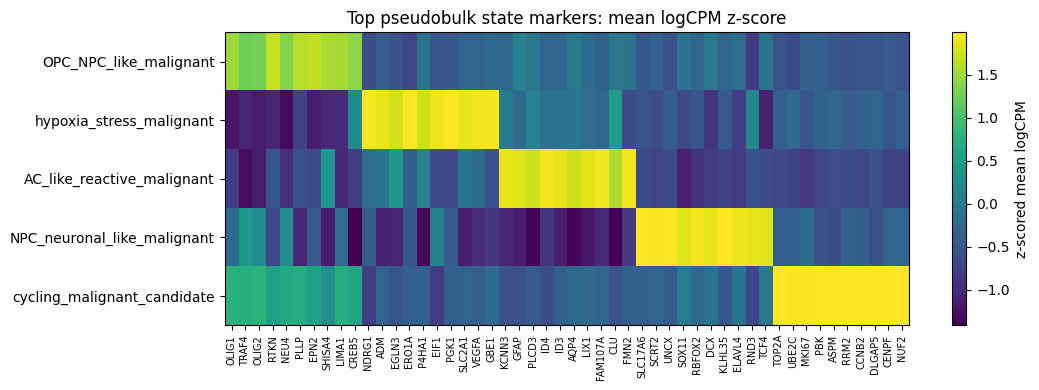

[SAVED] G:\Repository\glioma-cnv-single-cell-atlas\metadata\malignant_state_pseudobulk_top_marker_mean_logCPM_matrix_HVG8000_r0_6.tsv shape=(5, 51)
[SAVED] G:\Repository\glioma-cnv-single-cell-atlas\metadata\malignant_state_pseudobulk_DE_figure_manifest_HVG8000_r0_6.tsv shape=(1, 3)


,figure,path,description
0,malignant_state_pseudobulk_top_marker_heatmap,G:\Repository\glioma-cnv-single-cell-atlas\fig...,Heatmap of top pseudobulk up-marker genes per ...


PASS: historical pseudobulk marker heatmap reproduced.


In [12]:
# =========================
# 11. Historical pseudobulk marker heatmap
# =========================
figure_rows = []


heatmap_genes = []


for state in valid_states:
    sub = top_df[
        (
            top_df[
                "malignant_state"
            ]
            == state
        )
        & (
            top_df[
                "top_direction"
            ]
            == "top_up_in_state"
        )
    ].copy()


    sub = (
        sub
        .sort_values(
            [
                "padj_fdr_bh",
                "logFC_logCPM_state_vs_rest",
            ],
            ascending=[
                True,
                False,
            ],
        )
        .head(
            10
        )
    )


    heatmap_genes.extend(
        sub[
            "gene"
        ].tolist()
    )


seen = set()


heatmap_genes = [
    gene
    for gene in heatmap_genes
    if not (
        gene
        in seen
        or seen.add(
            gene
        )
    )
]


heatmap_genes = [
    gene
    for gene in heatmap_genes
    if gene in pb_adata.var_names
]


print(
    "n heatmap genes:",
    len(
        heatmap_genes
    ),
)


if len(
    heatmap_genes
) != 50:
    raise RuntimeError(
        "Historical heatmap-gene count checkpoint failed: "
        f"{len(heatmap_genes)} != 50"
    )


mean_rows = []


for state in valid_states:
    mask = (
        (
            pb_adata.obs[
                state_norm_col
            ]
            .astype(str)
            .values
            == state
        )
        & (
            pb_adata.obs[
                "n_cells"
            ].values
            >= MIN_CELLS_PER_PSEUDOBULK
        )
    )


    if mask.sum() == 0:
        continue


    vals = np.asarray(
        pb_adata[
            mask,
            heatmap_genes,
        ].X
    ).mean(
        axis=0
    )


    mean_rows.append(
        pd.Series(
            vals,
            index=heatmap_genes,
            name=state,
        )
    )


mean_df = pd.DataFrame(
    mean_rows
)


mat = (
    mean_df
    .values
    .astype(float)
)


mat_z = (
    mat
    - np.nanmean(
        mat,
        axis=0,
        keepdims=True,
    )
) / (
    np.nanstd(
        mat,
        axis=0,
        keepdims=True,
    )
    + 1e-8
)


fig_w = max(
    10,
    len(
        heatmap_genes
    )
    * 0.22,
)

fig_h = max(
    4,
    len(
        mean_df
    )
    * 0.55,
)


plt.figure(
    figsize=(
        fig_w,
        fig_h,
    )
)

plt.imshow(
    mat_z,
    aspect="auto",
)

plt.colorbar(
    label="z-scored mean logCPM"
)

plt.yticks(
    np.arange(
        len(
            mean_df.index
        )
    ),
    mean_df.index,
)

plt.xticks(
    np.arange(
        len(
            heatmap_genes
        )
    ),
    heatmap_genes,
    rotation=90,
    fontsize=7,
)

plt.title(
    "Top pseudobulk state markers: mean logCPM z-score"
)

plt.tight_layout()


fig_path = (
    FIGURES_DIR
    / "malignant_state_pseudobulk_top_marker_heatmap.png"
)


if fig_path.exists():
    fig_path.unlink()


plt.savefig(
    fig_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()


figure_rows.append(
    {
        "figure": "malignant_state_pseudobulk_top_marker_heatmap",
        "path": str(
            fig_path
        ),
        "description": (
            "Heatmap of top pseudobulk up-marker genes per malignant state, "
            "using z-scored mean logCPM across states."
        ),
    }
)


write_tsv_replace(
    mean_df.reset_index(
        names="malignant_state"
    ),
    MEAN_EXPR_TSV,
)


fig_manifest = pd.DataFrame(
    figure_rows
)


write_tsv_replace(
    fig_manifest,
    FIGURE_MANIFEST_TSV,
)


if fig_manifest.shape != (
    1,
    3,
):
    raise RuntimeError(
        f"Historical figure-manifest checkpoint failed: {fig_manifest.shape}"
    )


if mean_df.shape != (
    5,
    50,
):
    raise RuntimeError(
        f"Historical mean-expression matrix checkpoint failed: {mean_df.shape}"
    )


display(
    fig_manifest
)


print(
    "PASS: historical pseudobulk marker heatmap reproduced."
)


In [13]:
# =========================
# 12. Output manifest + cleanup + final checkpoints
# =========================
outputs = [
    (
        "READINESS_TSV",
        READINESS_TSV,
    ),
    (
        "PSEUDOBULK_QC_TSV",
        PSEUDOBULK_QC_TSV,
    ),
    (
        "STATE_SUMMARY_TSV",
        STATE_SUMMARY_TSV,
    ),
    (
        "PSEUDOBULK_H5AD",
        PSEUDOBULK_H5AD,
    ),
    (
        "DE_TOP100_TSV",
        DE_TOP100_TSV,
    ),
    (
        "DE_SIGNIFICANT_TSV",
        DE_SIGNIFICANT_TSV,
    ),
    (
        "DE_ALL_SUMMARY_TSV",
        DE_ALL_SUMMARY_TSV,
    ),
    (
        "REFINEMENT_SUMMARY_TSV",
        REFINEMENT_SUMMARY_TSV,
    ),
    (
        "FIGURE_MANIFEST_TSV",
        FIGURE_MANIFEST_TSV,
    ),
]


manifest = pd.DataFrame(
    [
        {
            "label": label,
            "path": str(
                path
            ),
            "exists": Path(
                path
            ).exists(),
            "size_mb": (
                round(
                    Path(
                        path
                    ).stat().st_size
                    / 1024
                    / 1024,
                    3,
                )
                if Path(
                    path
                ).exists()
                else np.nan
            ),
        }
        for label, path
        in outputs
    ]
)


write_tsv_replace(
    manifest,
    OUTPUT_MANIFEST_TSV,
)


if manifest.shape != (
    9,
    4,
):
    raise RuntimeError(
        f"Historical output-manifest checkpoint failed: {manifest.shape}"
    )


if not manifest[
    "exists"
].all():
    raise RuntimeError(
        "One or more expected Notebook-21 outputs are missing."
    )


display(
    manifest
)


# Remove restart chunks only after every historical output checkpoint passed.
try:
    if CHUNK_DIR.exists():
        shutil.rmtree(
            CHUNK_DIR
        )

        print(
            "[REMOVED COMPLETED SCRATCH CHUNKS]",
            CHUNK_DIR,
        )

except Exception as error:
    print(
        "[WARNING] Could not remove completed scratch chunks:",
        repr(
            error
        ),
    )


print(
    "\nFINAL CHECKPOINTS"
)

print(
    "Historical notebook mapping:",
    "20_malignant_state_pseudobulk_DE_HVG8000_r0_6.ipynb "
    "-> 21_malignant_state_pseudobulk.ipynb",
)

print(
    "Canonical Notebook-20 input:",
    INPUT_H5AD,
)

print(
    "Source shape:",
    source_shape,
)

print(
    "Malignant-state counts:",
    EXPECTED_STATE_COUNTS,
)

print(
    "Readiness:",
    readiness.shape,
)

print(
    "Pseudobulk QC:",
    group_counts.shape,
)

print(
    "Total pseudobulks:",
    group_counts.shape[
        0
    ],
)

print(
    "Passing pseudobulks:",
    int(
        group_counts[
            "passes_min_cells"
        ].sum()
    ),
)

print(
    "Pseudobulk H5AD:",
    pb_adata.shape,
)

print(
    "State summary:",
    state_summary.shape,
)

print(
    "DE-filtered pseudobulks:",
    pb.shape,
)

print(
    "DE test summary:",
    test_summary_df.shape,
)

print(
    "Top100 up/down:",
    top_df.shape,
)

print(
    "Significant markers:",
    sig_df.shape,
)

print(
    "Marker refinement summary:",
    refinement_summary.shape,
)

print(
    "Heatmap genes:",
    len(
        heatmap_genes
    ),
)

print(
    "Mean-expression matrix:",
    mean_df.shape,
)

print(
    "Figure manifest:",
    fig_manifest.shape,
)

print(
    "Output manifest:",
    manifest.shape,
)

print(
    "\n[DONE] Notebook 21 canonical malignant-state pseudobulk DE completed."
)


[SAVED] G:\Repository\glioma-cnv-single-cell-atlas\metadata\malignant_state_pseudobulk_DE_output_manifest_HVG8000_r0_6.tsv shape=(9, 4)


,label,path,exists,size_mb
0,READINESS_TSV,G:\Repository\glioma-cnv-single-cell-atlas\met...,True,0.001
1,PSEUDOBULK_QC_TSV,G:\Repository\glioma-cnv-single-cell-atlas\met...,True,0.039
2,STATE_SUMMARY_TSV,G:\Repository\glioma-cnv-single-cell-atlas\met...,True,0.000
3,PSEUDOBULK_H5AD,G:\Repository\glioma-cnv-single-cell-atlas\dat...,True,44.099
4,DE_TOP100_TSV,G:\Repository\glioma-cnv-single-cell-atlas\met...,True,0.210
5,DE_SIGNIFICANT_TSV,G:\Repository\glioma-cnv-single-cell-atlas\met...,True,4.170
6,DE_ALL_SUMMARY_TSV,G:\Repository\glioma-cnv-single-cell-atlas\met...,True,0.001
7,REFINEMENT_SUMMARY_TSV,G:\Repository\glioma-cnv-single-cell-atlas\met...,True,0.001
8,FIGURE_MANIFEST_TSV,G:\Repository\glioma-cnv-single-cell-atlas\met...,True,0.000


[REMOVED COMPLETED SCRATCH CHUNKS] E:\glioma-cnv-scratch\main_analysis_21\pseudobulk_count_chunks

FINAL CHECKPOINTS
Historical notebook mapping: 20_malignant_state_pseudobulk_DE_HVG8000_r0_6.ipynb -> 21_malignant_state_pseudobulk.ipynb
Canonical Notebook-20 input: G:\Repository\glioma-cnv-single-cell-atlas\data\processed\integrated\GBM_core_4datasets_final_annotation_malignant_states.h5ad
Source shape: (351427, 15176)
Malignant-state counts: {'not_malignant_state': 189543, 'OPC_NPC_like_malignant': 61646, 'cycling_malignant_candidate': 38634, 'hypoxia_stress_malignant': 32896, 'AC_like_reactive_malignant': 22525, 'NPC_neuronal_like_malignant': 6183}
Readiness: (1, 15)
Pseudobulk QC: (375, 7)
Total pseudobulks: 375
Passing pseudobulks: 290
Pseudobulk H5AD: (375, 15176)
State summary: (5, 10)
DE-filtered pseudobulks: (290, 15176)
DE test summary: (5, 10)
Top100 up/down: (1000, 19)
Significant markers: (20800, 18)
Marker refinement summary: (5, 11)
Heatmap genes: 50
Mean-expression matri

## Expected historical checkpoints

A successful run should end with:

```text
Source shape: (351427, 15176)

Malignant-state counts:
    not_malignant_state             189543
    OPC_NPC_like_malignant           61646
    cycling_malignant_candidate      38634
    hypoxia_stress_malignant         32896
    AC_like_reactive_malignant       22525
    NPC_neuronal_like_malignant       6183

Readiness: (1, 15)
Pseudobulk QC: (375, 7)
Total pseudobulks: 375
Passing pseudobulks: 290
Pseudobulk H5AD: (375, 15176)
State summary: (5, 10)
DE-filtered pseudobulks: (290, 15176)
DE test summary: (5, 10)
Top100 up/down: (1000, 19)
Significant markers: (20800, 18)
Marker refinement summary: (5, 11)
Heatmap genes: 50
Mean-expression matrix: (5, 50)
Figure manifest: (1, 3)
Output manifest: (9, 4)
```

The notebook also hard-checks historical pseudobulk counts, passing-unit counts, state-level library-size summaries, DE significance totals, first top-up markers, and extreme logFC genes.